In [ ]:
pip install torch torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.9 MB/s eta 0:00:00


In [ ]:
"""
Over-Smoothing Investigation Project
Includes:
  - plain / residual / pairnorm / dropedge
  - similarity & variance
  - overall accuracy (acc_all)
  - accuracy printed next to loss
  - corrected residuals (no shape mismatch)
Continuous-time GNN removed to avoid dimension issues.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.utils import dropout_edge


# ======================================
# 1. METRICS
# ======================================

@torch.no_grad()
def feature_similarity(x):
    x = F.normalize(x, p=2, dim=1)
    sim = x @ x.t()
    n = x.size(0)
    return (sim.sum() - sim.diag().sum()) / (n * n - n)


@torch.no_grad()
def feature_variance(x):
    return x.var(dim=0).mean()


# ======================================
# 2. PairNorm
# ======================================

class PairNorm(nn.Module):
    def __init__(self, scale=1.0):
        super().__init__()
        self.scale = scale

    def forward(self, x):
        col_mean = x.mean(dim=0, keepdim=True)
        x = x - col_mean
        row_norm = torch.sqrt(x.pow(2).sum(dim=1, keepdim=True)) + 1e-6
        return self.scale * x / row_norm.mean()


# ======================================
# 3. DeepGCN (Correct Residual Implementation)
# ======================================

class DeepGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers, variant="plain", dropedge_prob=0.2):

        super().__init__()
        self.variant = variant
        self.num_layers = num_layers
        self.dropedge_prob = dropedge_prob

        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))

        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        self.convs.append(GCNConv(hidden_channels, out_channels))

        self.pairnorm = PairNorm() if variant == "pairnorm" else None
        self.dropout = 0.5

    def _maybe_drop_edge(self, edge_index):
        if self.variant == "dropedge" and self.training:
            return dropout_edge(edge_index, p=self.dropedge_prob)[0]
        return edge_index

    def forward(self, x, edge_index, return_all=False):
        layer_outputs = [x]
        h = x

        for i, conv in enumerate(self.convs):

            ei = self._maybe_drop_edge(edge_index)
            h_in = h  # for residual

            h = conv(h, ei)

            # non-final layer operations
            if i != len(self.convs) - 1:
                h = F.relu(h)
                h = F.dropout(h, p=self.dropout, training=self.training)

                # PairNorm
                if self.variant == "pairnorm":
                    h = self.pairnorm(h)

                # Safe residual (only if dims match)
                if self.variant == "residual" and h.shape == h_in.shape:
                    h = h + h_in

            layer_outputs.append(h)

        if return_all:
            return h, layer_outputs
        return h


# ======================================
# 4. TRAINING / EVALUATION
# ======================================

def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data):
    model.eval()
    out, layers = model(data.x, data.edge_index, return_all=True)
    pred = out.argmax(dim=1)

    acc_train = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
    acc_val   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean().item()
    acc_test  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean().item()

    acc_all = (pred == data.y).float().mean().item()  # overall accuracy

    similarity = [feature_similarity(h).item() for h in layers]
    variance   = [feature_variance(h).item() for h in layers]

    return acc_train, acc_val, acc_test, acc_all, similarity, variance


# ======================================
# 5. RUN EXPERIMENT
# ======================================

def run_experiment(dataset_name="Cora",
                   depths=[2, 4, 8],
                   variants=["plain", "residual", "pairnorm", "dropedge"],
                   hidden_channels=64,
                   epochs=200):

    dataset = Planetoid(root="./data", name=dataset_name)
    data = dataset[0].to(device)

    results = {}

    for variant in variants:
        print(f"\n=== Variant: {variant.upper()} ===")

        for depth in depths:
            print(f"\n--> Depth = {depth} layers")

            model = DeepGCN(
                dataset.num_node_features,
                hidden_channels,
                dataset.num_classes,
                depth,
                variant=variant
            ).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

            best_val = 0
            best_test = 0

            for epoch in range(1, epochs + 1):
                loss = train(model, data, optimizer)
                acc_train, acc_val, acc_test, acc_all, _, _ = evaluate(model, data)

                if acc_val > best_val:
                    best_val = acc_val
                    best_test = acc_test

                # print every 20 epochs
                if epoch % 20 == 0 or epoch == 1:
                    print(
                        f"Epoch {epoch:03d} | "
                        f"Loss: {loss:.4f} | "
                        f"Accuracy: {acc_all:.3f} | "
                        f"Train: {acc_train:.3f} | "
                        f"Val: {acc_val:.3f} | "
                        f"Test: {acc_test:.3f}"
                    )

            # final eval
            acc_train, acc_val, acc_test, acc_all, sim, var = evaluate(model, data)

            print(f"\n[Depth={depth}, {variant}] Best Val Acc: {best_val:.3f}, Corresponding Test Acc: {best_test:.3f}")
            print("Layer-wise Feature Similarity:")
            for i, s in enumerate(sim):
                print(f"  Layer {i}: {s:.4f}")
            print("Layer-wise Feature Variance:")
            for i, v in enumerate(var):
                print(f"  Layer {i}: {v:.4f}")
            print("----------------------------------------")

            results[(variant, depth)] = {
                "train_acc": acc_train,
                "val_acc": acc_val,
                "test_acc": acc_test,
                "overall_accuracy": acc_all,
                "similarity": sim,
                "variance": var
            }

    return results


# ======================================
# 6. RUN
# ======================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import sys
sys.argv = ['']  # Fix for Colab

results = run_experiment()
print("Finished.")


Processing...
Done!



=== Variant: PLAIN ===

--> Depth = 2 layers
Epoch 001 | Loss: 1.9452 | Accuracy: 0.512 | Train: 0.829 | Val: 0.482 | Test: 0.496
Epoch 020 | Loss: 0.0187 | Accuracy: 0.804 | Train: 1.000 | Val: 0.770 | Test: 0.790
Epoch 040 | Loss: 0.0094 | Accuracy: 0.804 | Train: 1.000 | Val: 0.770 | Test: 0.794
Epoch 060 | Loss: 0.0141 | Accuracy: 0.813 | Train: 1.000 | Val: 0.772 | Test: 0.810
Epoch 080 | Loss: 0.0142 | Accuracy: 0.808 | Train: 1.000 | Val: 0.770 | Test: 0.800
Epoch 100 | Loss: 0.0124 | Accuracy: 0.809 | Train: 1.000 | Val: 0.762 | Test: 0.806
Epoch 120 | Loss: 0.0121 | Accuracy: 0.812 | Train: 1.000 | Val: 0.766 | Test: 0.809
Epoch 140 | Loss: 0.0124 | Accuracy: 0.811 | Train: 1.000 | Val: 0.774 | Test: 0.806
Epoch 160 | Loss: 0.0111 | Accuracy: 0.809 | Train: 1.000 | Val: 0.768 | Test: 0.806
Epoch 180 | Loss: 0.0109 | Accuracy: 0.811 | Train: 1.000 | Val: 0.772 | Test: 0.806
Epoch 200 | Loss: 0.0101 | Accuracy: 0.816 | Train: 1.000 | Val: 0.776 | Test: 0.811

[Depth=2, plain] B

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
def plot_accuracy_vs_depth(results):
    plt.figure(figsize=(8, 6))

    variants = sorted(list(set([k[0] for k in results.keys()])))
    depths   = sorted(list(set([k[1] for k in results.keys()])))

    for variant in variants:
        accs = []
        for depth in depths:
            accs.append(results[(variant, depth)]["test_acc"])
        plt.plot(depths, accs, marker='o', label=variant)

    plt.xlabel("Depth (# of GCN Layers)")
    plt.ylabel("Test Accuracy")
    plt.title("Test Accuracy vs Depth Across Variants")
    plt.grid(True)
    plt.legend()
    plt.show()


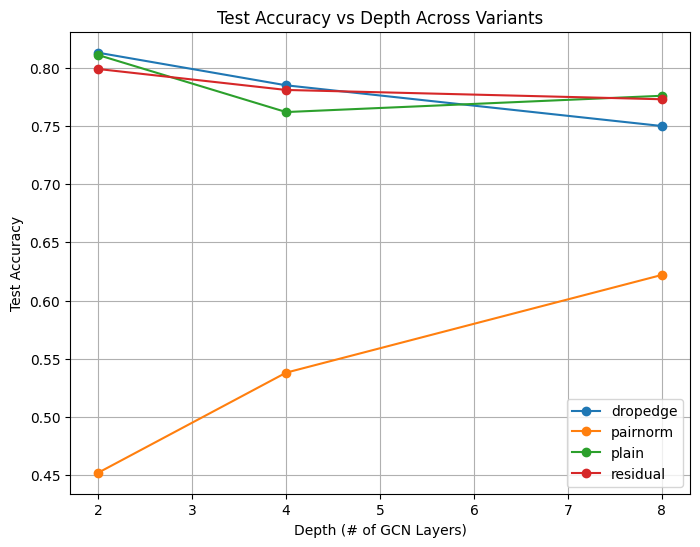

In [ ]:
plot_accuracy_vs_depth(results)


In [ ]:
def plot_similarity_for_variant(results, variant, depth):
    sim = results[(variant, depth)]["similarity"]

    plt.figure(figsize=(8, 6))
    plt.plot(range(len(sim)), sim, marker="o", linewidth=2)
    plt.xlabel("Layer Index")
    plt.ylabel("Feature Similarity")
    plt.title(f"Similarity Curve — {variant}, depth={depth}")
    plt.grid(True)
    plt.show()


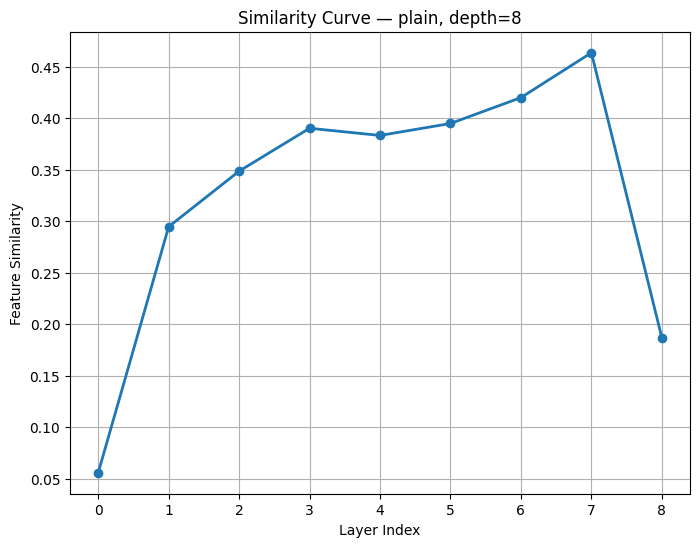

In [ ]:
plot_similarity_for_variant(results, "plain", 8)


In [ ]:
def plot_variance_for_variant(results, variant, depth):
    var = results[(variant, depth)]["variance"]

    plt.figure(figsize=(8, 6))
    plt.plot(range(len(var)), var, marker="o", linewidth=2)
    plt.xlabel("Layer Index")
    plt.ylabel("Feature Variance")
    plt.title(f"Variance Curve — {variant}, depth={depth}")
    plt.grid(True)
    plt.show()


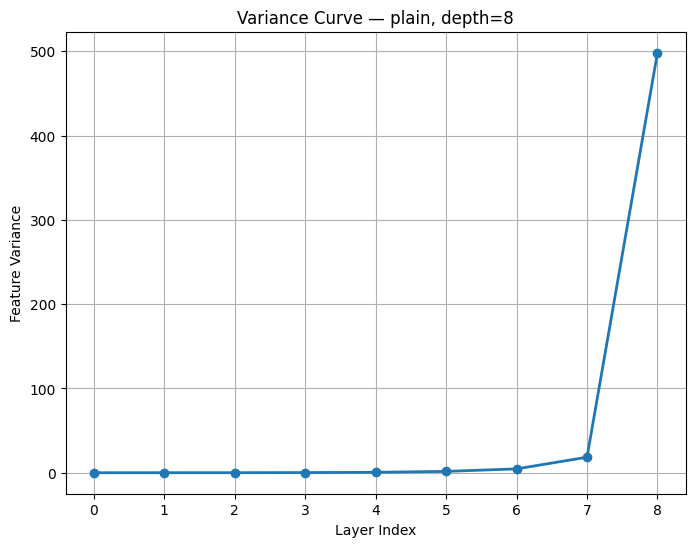

In [ ]:
plot_variance_for_variant(results, "plain", 8)


In [ ]:
def plot_sim_and_var(results, variant, depth):
    sim = results[(variant, depth)]["similarity"]
    var = results[(variant, depth)]["variance"]

    fig, ax1 = plt.subplots(figsize=(9, 5))

    ax1.set_xlabel("Layer Index")
    ax1.set_ylabel("Similarity", color="red")
    ax1.plot(sim, marker="o", color="red")
    ax1.tick_params(axis='y', labelcolor="red")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Variance", color="blue")
    ax2.plot(var, marker="s", color="blue")
    ax2.tick_params(axis='y', labelcolor="blue")

    plt.title(f"Similarity & Variance — {variant}, depth={depth}")
    plt.grid(True)
    plt.show()


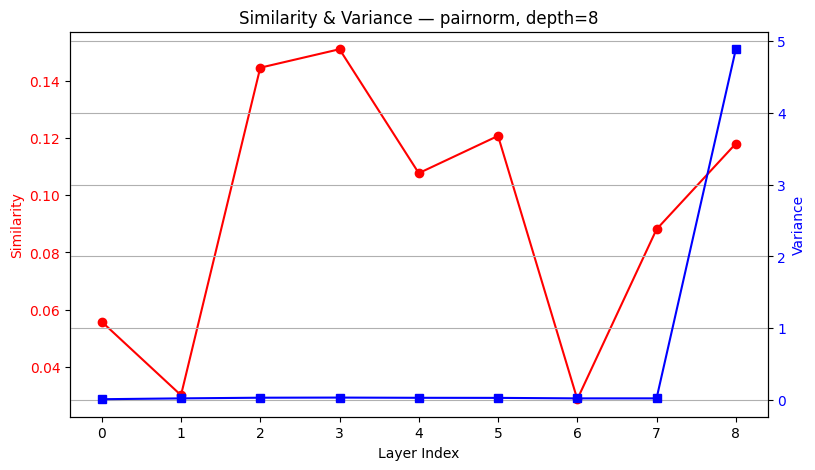

In [ ]:
plot_sim_and_var(results, "pairnorm", 8)


In [ ]:
def plot_similarity_heatmap(results, variant, depth):
    sim = results[(variant, depth)]["similarity"]
    sim_arr = np.array(sim).reshape(-1, 1)

    plt.figure(figsize=(4, 6))
    sns.heatmap(sim_arr, annot=True, cmap="viridis", cbar=True)
    plt.title(f"Similarity Heatmap — {variant}, depth={depth}")
    plt.ylabel("Layer")
    plt.xlabel("Similarity")
    plt.show()


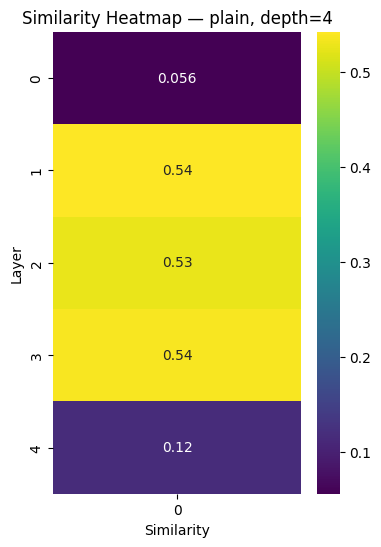

In [ ]:
plot_similarity_heatmap(results, "plain", 4)


In [ ]:
def plot_variance_heatmap(results, variant, depth):
    var = results[(variant, depth)]["variance"]
    var_arr = np.array(var).reshape(-1, 1)

    plt.figure(figsize=(4, 6))
    sns.heatmap(var_arr, annot=True, cmap="rocket", cbar=True)
    plt.title(f"Variance Heatmap — {variant}, depth={depth}")
    plt.ylabel("Layer")
    plt.xlabel("Variance")
    plt.show()


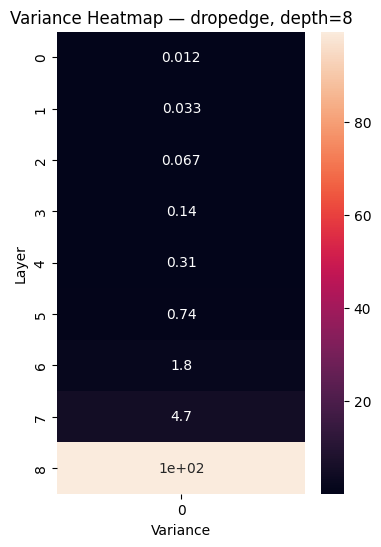

In [ ]:
plot_variance_heatmap(results, "dropedge", 8)


In [ ]:
def final_similarity_vs_depth(results):
    plt.figure(figsize=(8, 6))

    variants = sorted(list(set([k[0] for k in results.keys()])))
    depths   = sorted(list(set([k[1] for k in results.keys()])))

    for variant in variants:
        vals = []
        for depth in depths:
            vals.append(results[(variant, depth)]["similarity"][-1])
        plt.plot(depths, vals, marker='o', label=variant)

    plt.xlabel("Depth")
    plt.ylabel("Final Layer Similarity")
    plt.title("Over-Smoothing: Final Similarity vs Depth")
    plt.grid(True)
    plt.legend()
    plt.show()


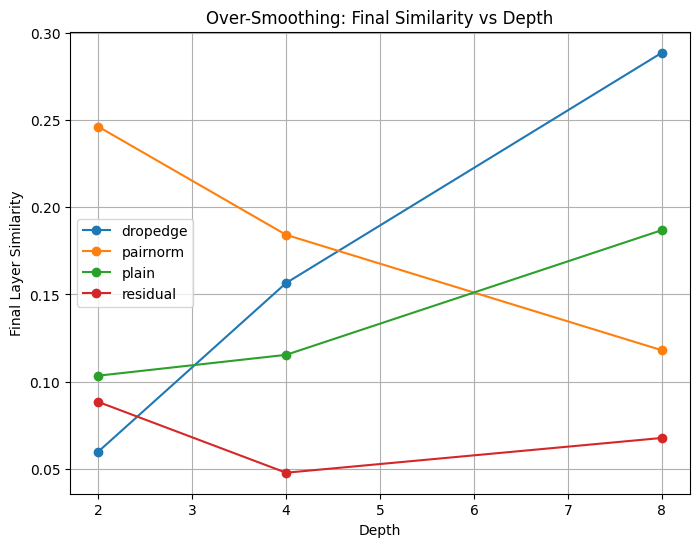

In [ ]:
final_similarity_vs_depth(results)

In [ ]:
def final_variance_vs_depth(results):
    plt.figure(figsize=(8, 6))

    variants = sorted(list(set([k[0] for k in results.keys()])))
    depths   = sorted(list(set([k[1] for k in results.keys()])))

    for variant in variants:
        vals = []
        for depth in depths:
            vals.append(results[(variant, depth)]["variance"][-1])
        plt.plot(depths, vals, marker='o', label=variant)

    plt.xlabel("Depth")
    plt.ylabel("Final Layer Variance")
    plt.title("Over-Smoothing: Final Variance vs Depth")
    plt.grid(True)
    plt.legend()
    plt.show()


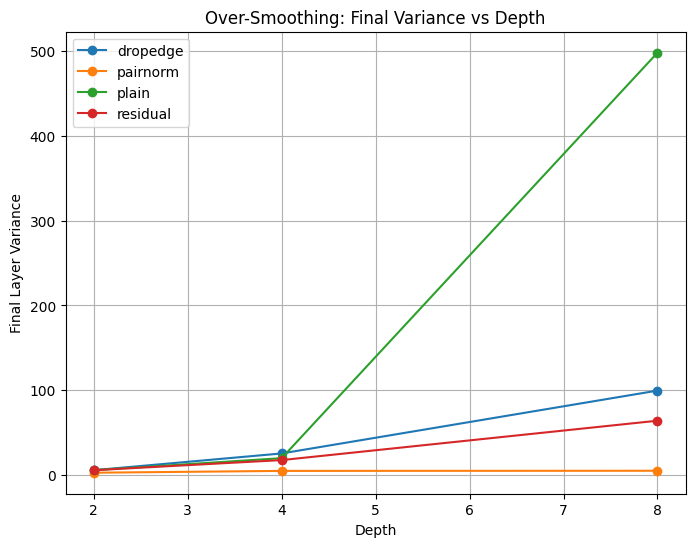

In [ ]:
final_variance_vs_depth(results)

In [ ]:
def plot_accuracy_per_variant(results):
    plt.figure(figsize=(7, 5))

    variants = sorted(list(set([k[0] for k in results.keys()])))

    accs = [np.mean([results[(v, d)]["test_acc"]
                     for d in [2, 4, 8]])
            for v in variants]

    plt.bar(variants, accs, color="skyblue")
    plt.ylabel("Avg Test Accuracy")
    plt.title("Average Test Accuracy by Variant")
    plt.show()


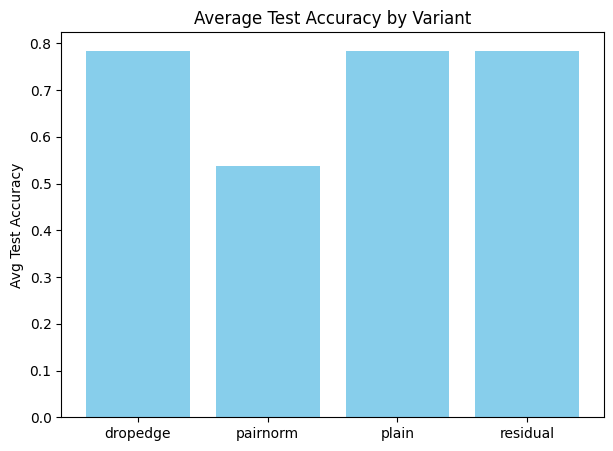

In [ ]:
plot_accuracy_per_variant(results)